In [2]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra

plt.style.use('default')
sns.set_theme()


In [3]:
import torch
import wandb
from dm_env import specs

import dmc
import utils
import uuid
from logger import Logger
from replay_buffer import ReplayBufferStorage, make_replay_loader

from video import TrainVideoRecorder, VideoRecorder
from collections import OrderedDict

from modulators import NoisySineModulator

You are using a GLFW raw input patch. This is not the official GLFW library.


/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/bin/../lib/libjpeg.9.dylib' (no su

In [4]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [5]:
domain = "humanoid"

In [6]:
from dmc_benchmark import (
    PRIMAL_TASKS,
    PRIMAL_TASKS_WALK,
    PRIMAL_TASKS_FAST_RUN,
    PRIMAL_TASKS_RUN_BACKWARD,
    CRL_TASKS_SAME_REWARD,
    CRL_TASKS_DIFF_REWARD,
    CRL_DIFF_DYNAMICS_DIFF_REWARD,
    CRL_TASKS_DIFF_RUN_SPEED_REWARD,
    CRL_DIFF_DOMAINS_SAME_REWARD,
    CRL_WALKER_WALK_RUN_TASKS,
    CRL_WALKER_STAND_RUN_TASKS,
    CRL_RUN_JUMP_TASKS,
    CRL_DIFF_DOMAINS_DIFF_REWARD,
    CRL_DIFF_DOMAINS_DIFF_REWARD_CHEETAH_FISH,
)

num_actions = {
    "cheetah": 6,
    "walker": 6,
    "quadruped": 12,
    "cartpole": 1,
    "humanoid": 21,
    "fish": 5,
    "dog": 38,
    "finger": 2,
}

In [7]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [8]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

max_len = 279 # by looking at PPO runs for humanoid

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    train_avg_episode_returns_history = run.scan_history(keys=["train/episode_reward"])
    train_avg_episode_reward = [
        row["train/episode_reward"] for row in train_avg_episode_returns_history
    ]

    update_steps_history = run.scan_history(keys=["train/update_step"])
    update_steps = [row["train/update_step"] for row in update_steps_history]

    steps_history = run.scan_history(keys=["train/step"])
    steps = [row["train/step"] for row in steps_history]

    if run.config["agent_name"] != "ppo":

        eval_avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
        eval_avg_episode_reward = [
            row["eval/episode_reward"] for row in eval_avg_episode_returns_history
        ]
        eval_steps_history = run.scan_history(keys=["eval/step"])
        eval_steps = [
            row["eval/step"] for row in eval_steps_history
        ]


    else:
        eval_avg_episode_reward = train_avg_episode_reward
        eval_steps = steps

    eval_update_steps = update_steps

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue

    print("len(update_steps): ", len(update_steps[:max_len]))
    print("len(train_avg_episode_reward: ", len(train_avg_episode_reward[:max_len]))

    if run.config["agent_name"] != "ppo":
        max_len = len(update_steps)
    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["train/step"] = steps[:max_len]
    temp["train/update_step"] = update_steps[:max_len]
    temp["train/episode_reward"] = train_avg_episode_reward[:max_len]

    temp["eval/episode_reward"] = eval_avg_episode_reward[:max_len]
    temp["eval/update_step"] = update_steps[:max_len]
    temp["eval/step"] = eval_steps[:max_len]

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 511
idx: 0
idx: 10
idx: 20
idx: 30
idx: 40
ddpg
len(update_steps):  279
len(train_avg_episode_reward:  279
ddpg
len(update_steps):  299
len(train_avg_episode_reward:  299
ddpg
len(update_steps):  299
len(train_avg_episode_reward:  299
ddpg
len(update_steps):  299
len(train_avg_episode_reward:  299
ddpg
len(update_steps):  299
len(train_avg_episode_reward:  299
idx: 50
idx: 60
ddpg_beakers_params_continuous
len(update_steps):  299
len(train_avg_episode_reward:  299
ddpg_beakers_params_continuous
len(update_steps):  299
len(train_avg_episode_reward:  299
ddpg_beakers_params_continuous
len(update_steps):  299
len(train_avg_episode_reward:  299
ddpg_beakers_params_continuous
len(update_steps):  299
len(train_avg_episode_reward:  299
ddpg_beakers_params_continuous
len(update_steps):  299
len(train_avg_episode_reward:  299
idx: 70
sf_simple_beakers_params
len(update_steps):  299
len(train_avg_episode_reward:  299
sf_simple_beakers_params
len(update_steps):  299
len(train_avg_epi

In [9]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

In [10]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC",
    "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
    "ppo": "PPO"
}

In [11]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [12]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [13]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [14]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [15]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [16]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [17]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [18]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [19]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [20]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [21]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ppo", agents_new_names["ppo"]
)

In [22]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['TD3' 'TD3 + SC' 'SF + SC (Ours)' 'SF' 'SF + EWC' 'TD3 + EWC'
 'SF + SC + Attention (Ours)' 'TD3 + CBP' 'TD3 + P-last' 'PPO']


In [23]:
print(runs_df)

                                              summary  \
0   {'train/step': [10000, 20000, 30000, 40000, 50...   
1   {'train/step': [10000, 20000, 30000, 40000, 50...   
2   {'train/step': [10000, 20000, 30000, 40000, 50...   
3   {'train/step': [10000, 20000, 30000, 40000, 50...   
4   {'train/step': [10000, 20000, 30000, 40000, 50...   
5   {'train/step': [10000, 20000, 30000, 40000, 50...   
6   {'train/step': [10000, 20000, 30000, 40000, 50...   
7   {'train/step': [10000, 20000, 30000, 40000, 50...   
8   {'train/step': [10000, 20000, 30000, 40000, 50...   
9   {'train/step': [10000, 20000, 30000, 40000, 50...   
10  {'train/step': [10000, 20000, 30000, 40000, 50...   
11  {'train/step': [10000, 20000, 30000, 40000, 50...   
12  {'train/step': [10000, 20000, 30000, 40000, 50...   
13  {'train/step': [10000, 20000, 30000, 40000, 50...   
14  {'train/step': [10000, 20000, 30000, 40000, 50...   
15  {'train/step': [10000, 20000, 30000, 40000, 50...   
16  {'train/step': [10000, 2000

In [24]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed']


In [25]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (54, 5)


In [26]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

                    agent_name  agent_seed  \
0                          TD3         679   
1                          TD3         582   
2                          TD3         291   
3                          TD3         388   
4                          TD3         485   
5                     TD3 + SC         388   
6                     TD3 + SC         485   
7                     TD3 + SC          97   
8                     TD3 + SC         291   
9                     TD3 + SC         679   
10              SF + SC (Ours)         194   
11              SF + SC (Ours)         291   
12              SF + SC (Ours)          97   
13              SF + SC (Ours)         388   
14              SF + SC (Ours)         485   
15                          SF         291   
16                          SF         194   
17                          SF         388   
18                          SF         485   
19                          SF          97   
20                    SF + EWC    

In [27]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    "PPO": "#17becf",
    # "SF + SC": "#ff7f0e",
    # "DDPG + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "DDPG",
#     "ddpg_beakers_params_continuous": "DDPG + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "DDPG + Plasticity (last layer)",
#     "ddpg_online_ewc": "DDPG (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "DDPG + Plasticity",
# }

In [28]:
# FOR PPO ANALYSIS ONLY

print(runs_df.columns)

runs_df["train/episode_rewards_num"] = (
    runs_df["train/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "train/step"])

runs_df["train/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["train/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["train/norm_cum_reward"] = runs_df["train/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'eval/step'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'eval/step', 'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')


In [29]:
# FOR PPO ANALYSIS ONLY

print(runs_df.columns)

runs_df["train/episode_rewards_num"] = (
    runs_df["train/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "train/step"])

runs_df["train/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["train/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["train/norm_cum_reward"] = runs_df["train/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'eval/step', 'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'train/step', 'train/update_step',
       'train/episode_reward', 'eval/episode_reward', 'eval/update_step',
       'eval/step', 'train/episode_rewards_num', 'train/cumulative_rewards',
       'episode_count', 'train/norm_cum_reward', 'agent_name_pretty'],
      dtype='object')


In [30]:
max_steps = runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]]["train/update_step"].max()
print("max_steps: ", max_steps)
print(runs_df[runs_df["agent_name"] == agents_new_names["ppo"]]["train/update_step"])

max_steps:  1490500.7499250076
14053            0
14054         2720
14055         8160
14056        13600
14057        19040
           ...    
16001    1495840.0
16002    1501280.0
16003    1506720.0
16004    1512160.0
16005    1517600.0
Name: train/update_step, Length: 1953, dtype: object


In [31]:
runs_df.loc[
    runs_df["agent_name"] == agents_new_names["sf_simple"],
    "train/update_step"
] = runs_df.loc[
    runs_df["agent_name"] == agents_new_names["ddpg"],
    "train/update_step"
].values

runs_df.loc[
    runs_df["agent_name"] == agents_new_names["sf_simple"],
    "eval/update_step"
] = runs_df.loc[
    runs_df["agent_name"] == agents_new_names["ddpg"],
    "eval/update_step"
].values

In [32]:
runs_df[runs_df["agent_name"] == agents_new_names["ppo"]] = runs_df[runs_df["agent_name"] == agents_new_names["ppo"]][runs_df[runs_df["agent_name"] == agents_new_names["ppo"]]["train/update_step"] <= 1390600]


In [33]:
from scipy.integrate import trapezoid

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/update_step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

In [34]:
runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]]["train/step"]

5681        10000
5682        20000
5683        30000
5684        40000
5685        50000
          ...    
5676    2950000.0
5677    2960000.0
5678    2970000.0
5679    2980000.0
5680    2990000.0
Name: train/step, Length: 1495, dtype: object

/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_95325/3729565642.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_95325/3729565642.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)
/var/f

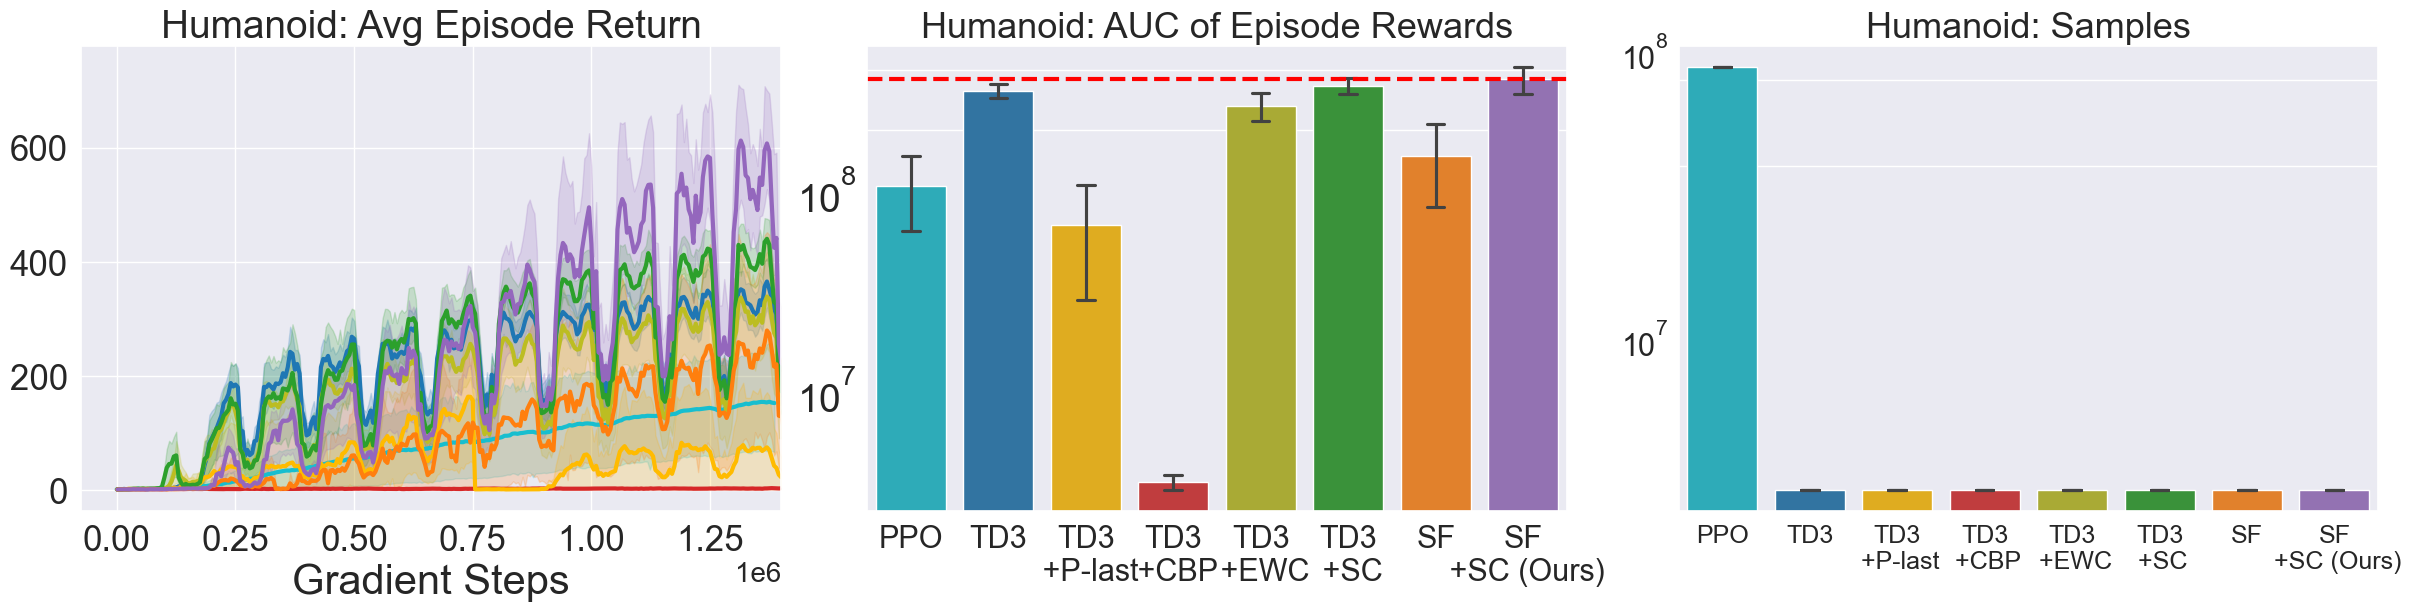

In [44]:
# FOR PPO ANALYSIS ONLY

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ppo"]],
    label=agents_new_names["ppo"],
    color=color_code[agents_new_names["ppo"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/update_step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# Right
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)

# agents_to_plot = ["PPO", "DDPG", "SF", "DDPG + SC", "SF + SC (Ours)",]
agents_to_plot = ["PPO", "TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)

# match the order in subset["agent_name_pretty"] with the order in agents_to_plot
subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)

eps = 1e-12  # in case any values are 0
subset = subset.copy()
# subset["AUC_log10"] = np.log10(subset["AUC"].clip(lower=eps))

# print(subset[subset["agent_name"] == agents_new_names["sf_simple"]]["AUC_log10"])


sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, ax=axes[1], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)


subset_last_rows = last_rows[last_rows["agent_name"].isin(agents_to_plot)]
subset_last_rows["agent_name_pretty"] = pd.Categorical(subset_last_rows["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)
sns.barplot(data=subset_last_rows, x="agent_name_pretty", y="train/step", palette=color_code, ax=axes[2], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

# for i, bar in enumerate(axes[1].patches):
#     x = bar.get_x()
#     y = bar.get_y()
#     w = bar.get_width()
#     h = bar.get_height()
#     if i % 2 == 0:
#         before = h
#     else:
#         pct_gain = 100 * (h - before) / before
#         if pct_gain > 0:
#             axes[1].text(
#                 bar.get_x() + bar.get_width()/2,
#                 bar.get_height() - 0.2 * axes[1].get_ylim()[1],
#                 f"+{pct_gain:.1f}%",
#                 ha="center", va="top", fontsize=25, fontweight="bold"
#             )
#
#         else:
#             axes[1].text(
#                 bar.get_x() + bar.get_width()/2,
#                 bar.get_height() - 0.2 * axes[1].get_ylim()[1],
#                 f"-{pct_gain:.1f}%",
#                 ha="center", va="top", fontsize=25, fontweight="bold"
#             )
#
#
#     print(i, x, y, w, h)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=28)
axes[0].set_xlabel("Gradient Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

# clip x-axis range to 1.4 million
axes[0].set_xlim(right=1_400_000)


axes[1].set_xlabel("", fontsize=22)
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Humanoid: AUC of Episode Rewards", fontsize=26)
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=28)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[1].tick_params(axis='y', which='minor', labelsize=28)


mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

axes[2].set_xlabel("", fontsize=14)
axes[2].set_ylabel("", fontsize=14)
axes[2].set_title("Humanoid: Samples", fontsize=26)
axes[2].tick_params(axis="x", labelsize=18)
axes[2].tick_params(axis="y", labelsize=22)
axes[2].set_yscale("log")
axes[2].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[2].yaxis.get_offset_text().set_fontsize(18)
axes[2].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[], numticks=10))
axes[2].tick_params(axis='y', which='minor', labelsize=22)


filename = "ppo_comparison_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


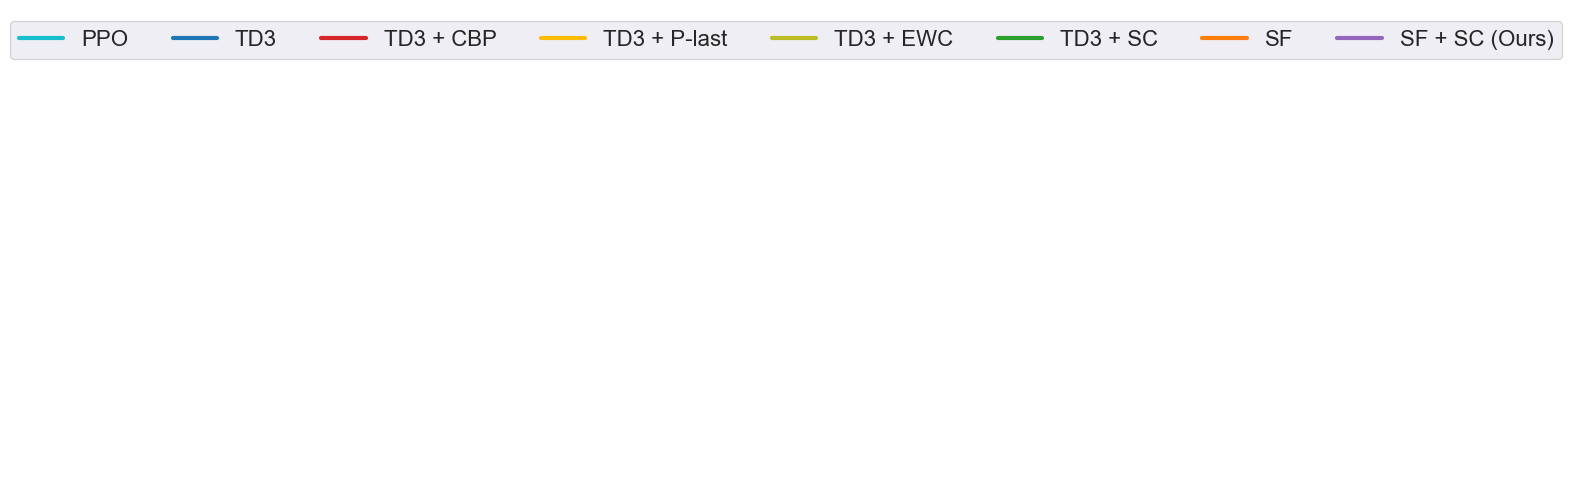

In [36]:
from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color=color_code[agents_new_names["ppo"]], lw=3, label=agents_new_names["ppo"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg"]], lw=3, label=agents_new_names["ddpg"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_continual_backprop"]], lw=3, label=agents_new_names["ddpg_continual_backprop"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]], lw=3, label=agents_new_names["ddpg_plasticity_injection_last_layer"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_online_ewc"]], lw=3, label=agents_new_names["ddpg_online_ewc"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_beakers_params_continuous"]], lw=3, label=agents_new_names["ddpg_beakers_params_continuous"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_simple"]], lw=3, label=agents_new_names["sf_simple"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_simple_beakers_params"]], lw=3, label=agents_new_names["sf_simple_beakers_params"]),

]

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis("off")               # hide axes
plt.legend(
    handles=custom_lines,
    loc="upper center",          # center horizontally
    bbox_to_anchor=(0.5, 1),  # (x=0.5 ﷿﷿﷿ center, y>1 ﷿﷿﷿ move upward)
    fontsize=16,
    ncol=8                       # optional: make legend entries spread in columns
)

filename = "ppo_make_title_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf")
plt.show()